In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt

In [79]:
font = {'family': 'sans-serif',
        'color':  'black',
        'weight': 'normal',
        'size': 20,
        }

In [103]:
'''
Load wind data for HadGEM3, ECHAM5, d4PDF
'''

d4PDF_ua = xr.open_dataarray('/nesi/project/niwa02986/queenle/data/d4pdf/NZ/HPB/UA/ua_zonal_d4PDF_HPB_ensMean_195101-201112.nc')
d4PDF_ua = d4PDF_ua.sel(time=slice('1979','2019'))
d4PDF_ua['lev'] = d4PDF_ua.lev*100 / 100
d4PDF_ua = d4PDF_ua.rename({'lev':'plev'})

ECHAM5_ua = xr.open_dataarray('/nesi/project/niwa02986/queenle/data/ECHAM5/ua_Amon-zonal-NZ_ECHAM5_all_ensMean_1979-2021.nc')
ECHAM5_ua = ECHAM5_ua.sel(time=slice('1979','2019'))
ECHAM5_ua = ECHAM5_ua.resample(time = 'QS-DEC').mean()
ECHAM5_ua['plev'] = ECHAM5_ua.plev / 100

HadGEM3_ua = xr.open_dataarray('/nesi/project/niwa02986/queenle/data/HadGEM3/ua_Amon-zonal-NZ_HadGEM3_all_ensMean_1960-2015.nc')
HadGEM3_ua = HadGEM3_ua.sel(time=slice('1979','2019'))
HadGEM3_ua = HadGEM3_ua.resample(time = 'QS-DEC').mean()
HadGEM3_ua['plev'] = HadGEM3_ua.plev / 100

# Read in ERA data
ERA5_ua = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/ERA5/ERA_u_zonal_wind.nc')
ERA5_ua = ERA5_ua.sel(time=slice('1979','2019'))
ERA5_ua = ERA5_ua.rename({'level':'plev'})
ERA5_ua['plev'] = ERA5_ua.plev*100
ERA5_ua['plev'] = ERA5_ua.plev / 100


da_dict = {'ERA5':ERA5_ua,
           'HadGEM3':HadGEM3_ua,
           'ECHAM5':ECHAM5_ua,
           'd4PDF-G':d4PDF_ua}


In [8]:
for model in da_dict:
    print(da_dict[model].shape)

(165, 37, 361)
(149, 17, 162)
(165, 17, 120)
(132, 24, 73)


In [109]:


for model in ['ERA5','HadGEM3','d4PDF-G','ECHAM5']:
    fig,axs = plt.subplots(2,2, figsize=(16,10), sharex=True,sharey=True, layout='constrained')

    seasons = ['(a) Winter','(b) Spring','(c) Summer','(d) Autumn']
    for i,season in enumerate([6,9,12,3]):
        
        ax = axs.flatten()[i]

        season = da_dict[model].sel(time=da_dict[model].time.dt.month.isin([season]))

        past = season.isel(time=slice(0,10)).mean('time')    
        present = season.isel(time=slice(-11,-1)).mean('time')

        diff = (present - past)

        im = past.plot.contourf(ax=ax,add_colorbar=False,cmap='bwr',vmin=-60,vmax=60,levels=31)

        cntr = diff.plot.contour(ax=ax,add_colorbar=False,colors='black',alpha=.7,levels=55,vmin=-9,vmax=9)

        ax.set_ylim(1000,0)

        ax.set_title(f'{seasons[i]}',fontdict=font)
        ax.axvspan(-46.56, -35.23, alpha=0.2, color='grey')
        if i < 2:
            ax.set_xlabel('')
        else:
            ax.set_xlabel('Latitude',fontdict=font)
            ax.set_xticks([-90+10*i for i in range(10)],labels=[str(-90+10*i) for i in range(10)],fontsize=18)
            
            
        if i == 0 or i == 2:
            ax.set_ylabel('Pressure (hPa)',fontdict=font)
            ax.set_yticks([1000-200*i for i in range(6)],labels=[str(1000-200*i) for i in range(6)],fontsize=18)
        else:
            ax.set_ylabel('')
        
    cb = fig.colorbar(im,ax=axs[0:2,0:2], shrink=0.85)
    cb.set_label(label='Eastward wind (m/s)',fontdict=font)
    cb.set_ticks([-60 + 20*i for i in range(7)],labels=[str(-60 + 20*i) for i in range(7)],fontsize=18)
    #cb.set_ticklabels([cb.ax.get_yticklabels()],fontdict=font,fontsize=14)

    plt.savefig('/home/queenle/hydro_attribution/dissertation/figures/supplemental_material/zonal_wind_map_'+model+'.png',dpi=300)
    #plt.show()
    plt.close()

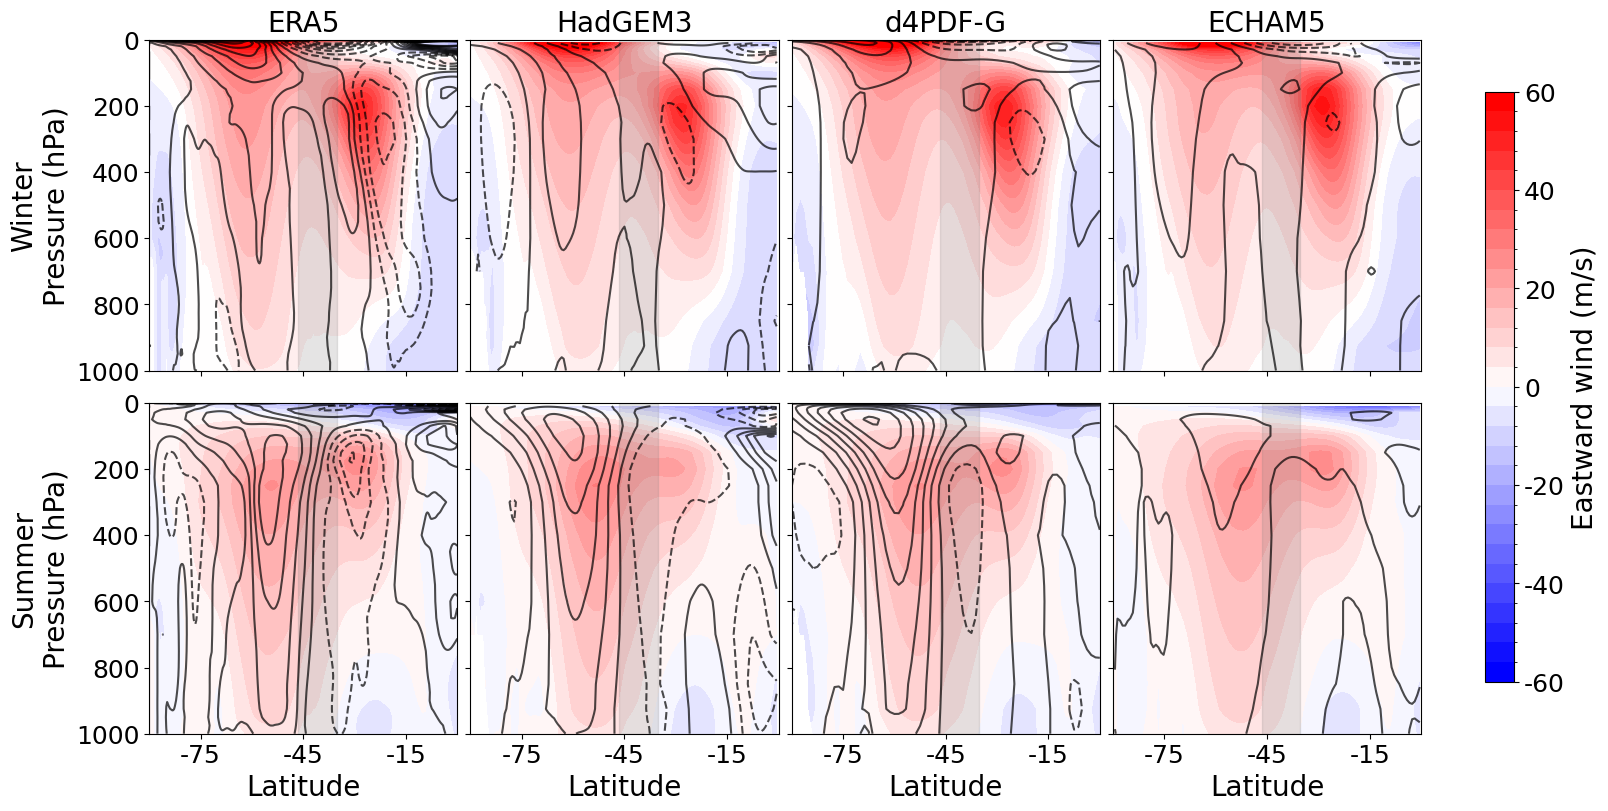

In [110]:
fig,axs = plt.subplots(2,4,figsize=(16,8), sharex=True,sharey=True, layout='constrained')

for j,model in enumerate(['ERA5','HadGEM3','d4PDF-G','ECHAM5']):
    
    model_da = da_dict[model]

    seasons = ['Winter','Summer']
    for i,season in enumerate([6,12]):
        
        ax = axs[i][j]

        season = model_da.sel(time=model_da.time.dt.month.isin([season])).sel(time=slice('1979','2019'))

        past = season.isel(time=slice(0,10)).mean('time')    
        present = season.isel(time=slice(-11,-1)).mean('time')

        diff = (present - past)

        im = past.plot.contourf(ax=ax,add_colorbar=False,cmap='bwr',vmin=-60,vmax=60,levels=31)

        if i == 0:
            cntr = diff.plot.contour(ax=ax,add_colorbar=False,colors='black',alpha=.7,vmin=-5,vmax=5,levels=15)
        elif i == 1:
            cntr = diff.plot.contour(ax=ax,add_colorbar=False,colors='black',alpha=.7,vmin=-5,vmax=5,levels=15)

        ax.set_ylim(1000,0)

        
        ax.axvspan(-46.56, -35.23, alpha=0.2, color='grey')
        
        if i == 0:
            ax.set_xlabel('')
            ax.set_title(f'{model}',fontdict=font)
        else:
            ax.set_xlabel('Latitude',fontdict=font)
            ax.set_xticks([-75,-45,-15],labels=['-75','-45','-15'],fontsize=18)
            ax.set_title('',fontdict=font)

        if j == 0:
            ax.set_ylabel(f'{seasons[i]}\nPressure (hPa)',fontdict=font)
            ax.set_yticks([1000-200*i for i in range(6)],labels=[str(1000-200*i) for i in range(6)],fontsize=18)
        else:
            ax.set_ylabel('')
        
cb = fig.colorbar(im,ax=axs[:,:], shrink=0.85)
cb.set_label(label='Eastward wind (m/s)',fontdict=font)
cb.set_ticks([-60 + 20*i for i in range(7)],labels=[str(-60 + 20*i) for i in range(7)],fontsize=18)
#cb.set_ticklabels([cb.ax.get_yticklabels()],fontdict=font,fontsize=14)

plt.savefig('/home/queenle/hydro_attribution/dissertation/figures/supplemental_material/zonal_wind_maps_figure.png',dpi=300)
plt.show()
plt.close()

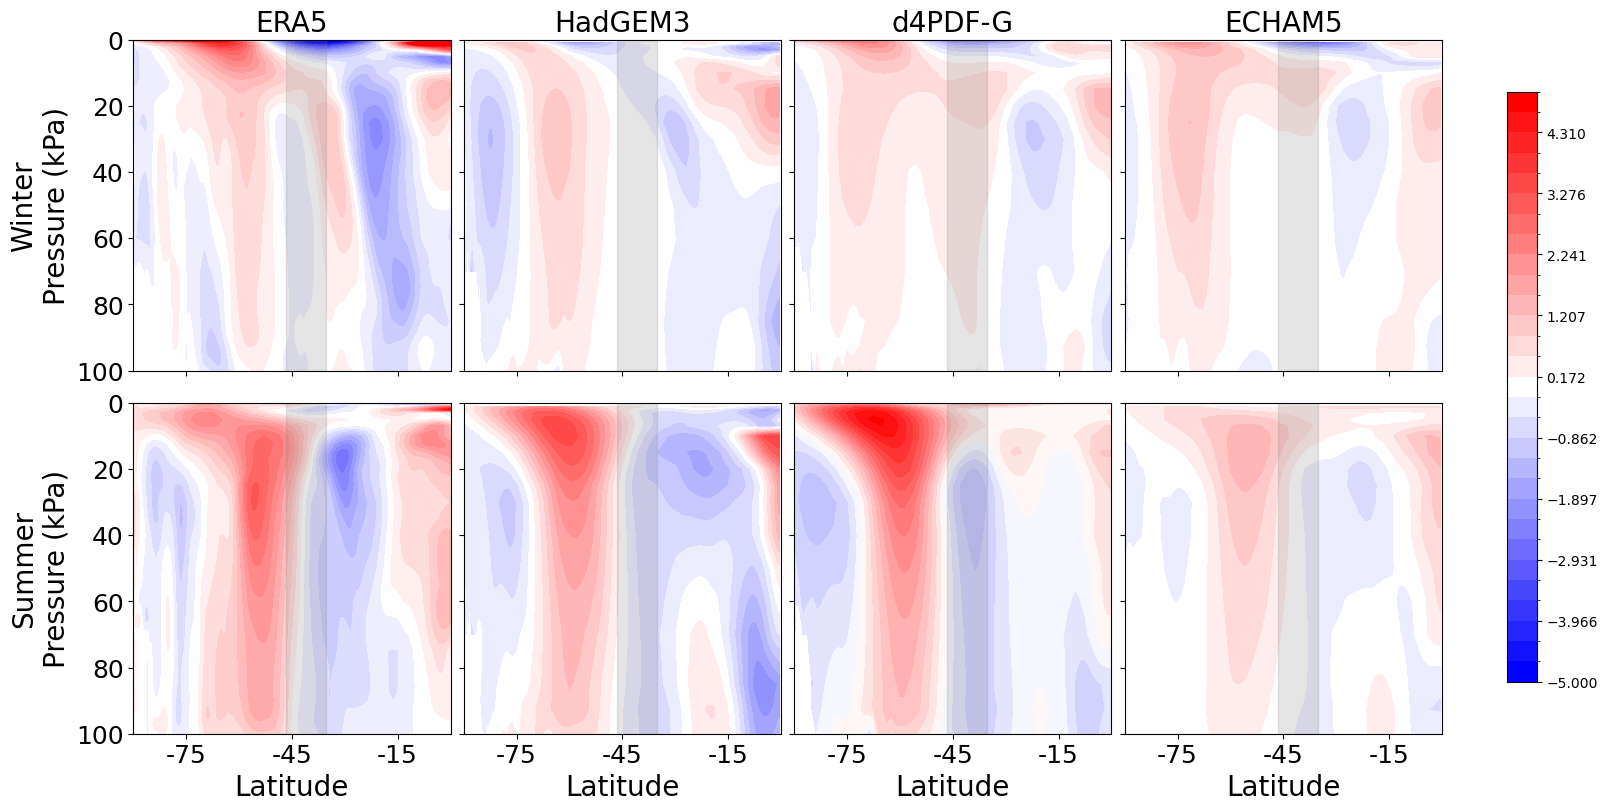

In [96]:
fig,axs = plt.subplots(2,4,figsize=(16,8), sharex=True,sharey=True, layout='constrained')

for j,model in enumerate(['ERA5','HadGEM3','d4PDF-G','ECHAM5']):
    
    model_da = da_dict[model]

    seasons = ['Winter','Summer']
    for i,season in enumerate([6,12]):
        
        ax = axs[i][j]

        season = model_da.sel(time=model_da.time.dt.month.isin([season]))

        past = season.isel(time=slice(0,10)).mean('time')    
        present = season.isel(time=slice(-11,-1)).mean('time')
        if model == 'd4PDF-G':
            present = season.isel(time=slice(-11,-1)).mean('time')

        diff = (present - past)

        im = diff.plot.contourf(ax=ax,add_colorbar=False,cmap='bwr',vmin=-5,vmax=5,levels=30)

        ax.set_ylim(100,0)

        
        ax.axvspan(-46.56, -35.23, alpha=0.2, color='grey')
        
        if i == 0:
            ax.set_xlabel('')
            ax.set_title(f'{model}',fontdict=font)
        else:
            ax.set_xlabel('Latitude',fontdict=font)
            ax.set_xticks([-75,-45,-15],labels=['-75','-45','-15'],fontsize=18)
            ax.set_title('',fontdict=font)

        if j == 0:
            ax.set_ylabel(f'{seasons[i]}\nPressure (kPa)',fontdict=font)
            ax.set_yticks([100-20*i for i in range(6)],labels=[str(100-20*i) for i in range(6)],fontsize=18)
        else:
            ax.set_ylabel('')
        
cb = fig.colorbar(im,ax=axs[:,:], shrink=0.85)
#cb.set_label(label='Eastward wind (m/s)',fontdict=font)
#cb.set_ticks([-60 + 20*i for i in range(7)],labels=[str(-60 + 20*i) for i in range(7)],fontsize=18)
#cb.set_ticklabels([cb.ax.get_yticklabels()],fontdict=font,fontsize=14)

#plt.savefig('/home/queenle/hydro_attribution/dissertation/figures/supplemental_material/zonal_wind_maps_figure.png',dpi=300)
plt.show()
plt.close()

In [85]:
da_dict['ERA5']

<xarray.DataArray 'u' (time: 164, plev: 37, latitude: 361)>
[2190548 values with dtype=float32]
Coordinates:
  * latitude  (latitude) float32 0.0 -0.25 -0.5 -0.75 ... -89.5 -89.75 -90.0
  * plev      (plev) float64 0.1 0.2 0.3 0.5 0.7 ... 90.0 92.5 95.0 97.5 100.0
    expver    int32 ...
  * time      (time) datetime64[ns] 1979-03-01 1979-06-01 ... 2019-12-01

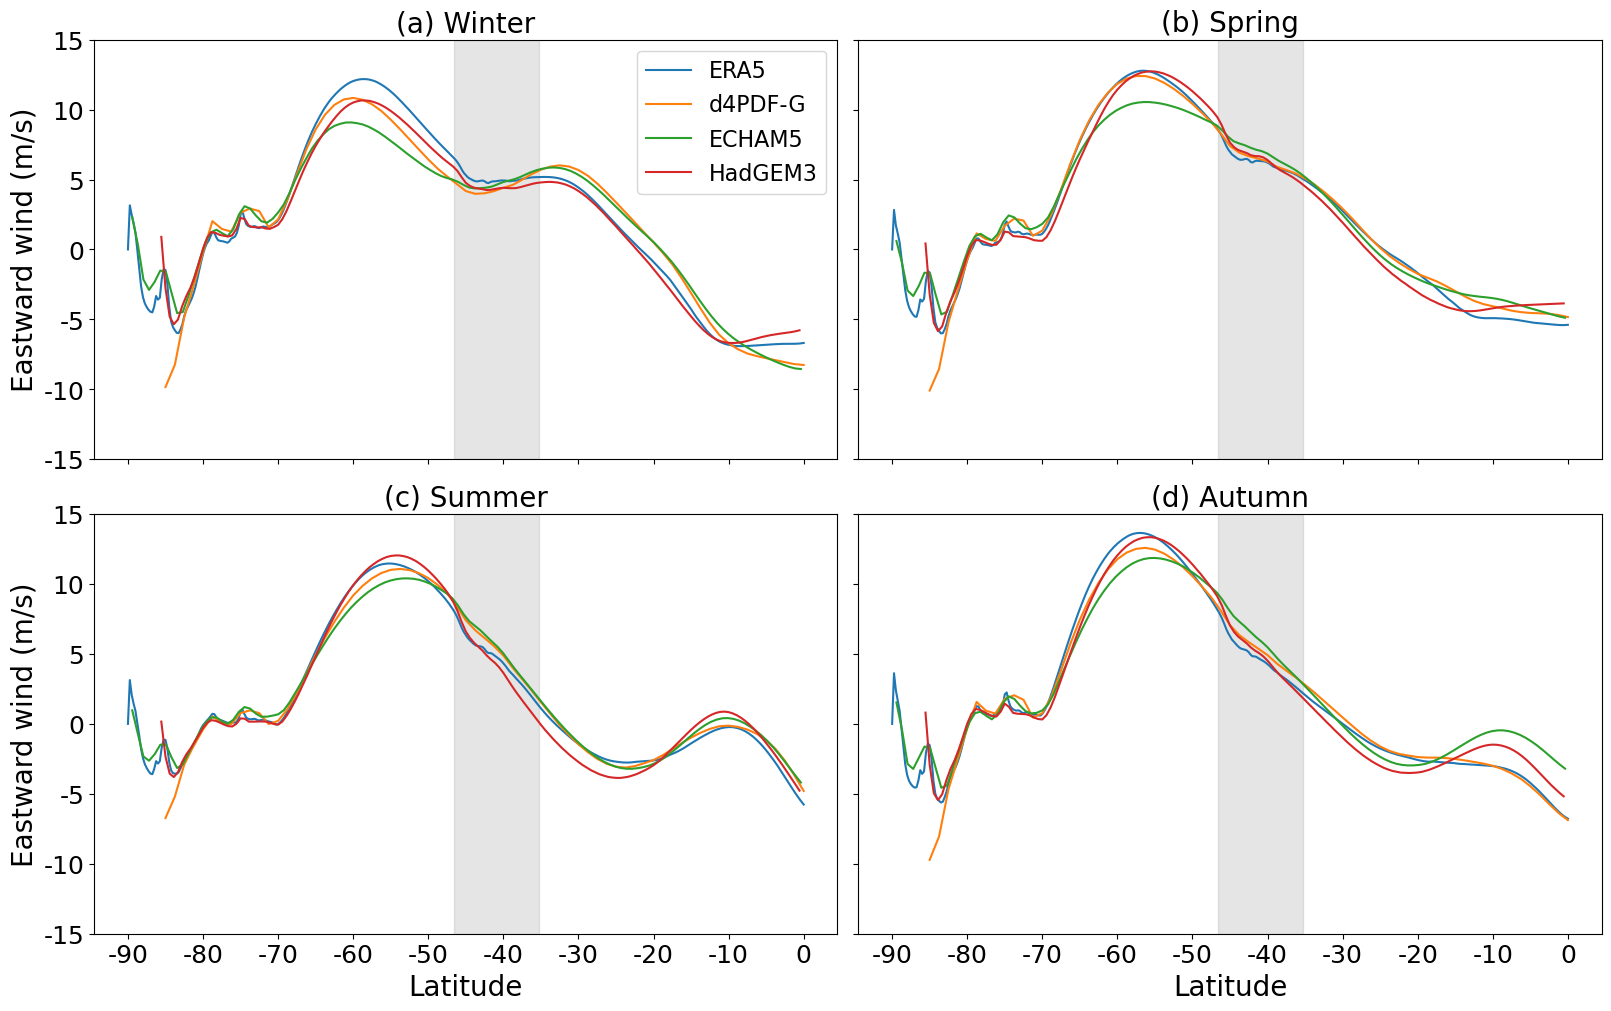

In [111]:
fig,axs = plt.subplots(2,2, figsize=(16,10), sharex=True,sharey=True,layout='constrained')
axs = axs.flatten()

seasons = ['(a) Winter','(b) Spring','(c) Summer','(d) Autumn']
for i,season in enumerate([6,9,12,3]):
    
    for model in ['ERA5','d4PDF-G','ECHAM5','HadGEM3']:
        da = da_dict[model].sel(time=da_dict[model].time.dt.month.isin([season]))

        da = da.sel(plev=850).mean('time') 
            
        da.plot(ax=axs[i],label=model)

    axs[i].set_title(f'{seasons[i]}',fontdict=font)
    axs[i].axvspan(-46.56, -35.23, alpha=0.2, color='grey')
    axs[i].set_ylim(-15,15)
    
    if i < 2:
        axs[i].set_xlabel('')
    else:
        axs[i].set_xlabel('Latitude',fontdict=font)
        axs[i].set_xticks([-90+10*i for i in range(10)],labels=[str(-90+10*i) for i in range(10)],fontsize=18)


    if i == 0 or i == 2:
        axs[i].set_ylabel('Eastward wind (m/s)',fontdict=font)
        axs[i].set_yticks([-15+5*i for i in range(7)],labels=[str(-15+5*i) for i in range(7)],fontsize=18)
    else:
        axs[i].set_ylabel('')
    
axs[0].legend(fontsize=16,loc='upper right')
        
plt.savefig('/home/queenle/hydro_attribution/dissertation/figures/supplemental_material/surface_wind.png',dpi=300)